# Used Car Prediction

In [461]:
import pandas as pd

df = pd.read_excel('./test/model_counts.xlsx')
# Split the columns in numeric and categorical features
numeric_features = ['Levy', 'Prod. year', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags']
categorical_features = ['Manufacturer', 'Category', 'Fuel type', 'Gear box type', 'Drive wheels', 'Color']

# Preprocessing & Feature Engineering

In [463]:
# Replacing '-' with a value very small that won't have any effect on the results.
df['Levy'].replace({'-': 0.0001}, inplace = True)
# Converting Levy to float.
df['Levy'] = df['Levy'].astype('float64')

#Convert Leather interior from string to binary 1 and 0
df['Leather interior'].replace({'Yes': 1, 'No':0}, inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_17336\1364703329.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Levy'].replace({'-': 0.0001}, inplace = True)
C:\Users\user\AppData\Local\Temp\ipykernel_17336\1364703329.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Leather interior'].replace({'Yes': 1, 'No':0}, inplace=True)


In [464]:
# Making sure that we have a standard in this case everything lower first
df['Engine volume'] = df['Engine volume'].str.lower()

# Finding the rows which has turbo in them and the results are added to a new column Turbo. 
df['Turbo'] = df['Engine volume'].str.contains('turbo').astype(float)

# Slicing engine Turbo and converting type to float
df['Engine volume'] = df['Engine volume'].str.slice(0,3)
df['Engine volume'] = df['Engine volume'].astype('float64')

# Strip km from mileage to convert in numeric values
df['Mileage'] = df['Mileage'].str.strip('km')
df['Mileage'] = df['Mileage'].astype('int64')

# To calculate the car_age we use 2020 because the dataset is from 2020 and not 2026
df['Car_Age'] = 2020 - df['Prod. year']

# Doors: simplify categories. Because excel reads doors as date we had to adapt.
df['Doors'] = df['Doors'].replace({
        '5/4/2026': '4',
        '3/2/2026': '2',
        '>5': '5'
})


# Drop unrealistic rows
​
Outlier rows with unrealistic values were removed before training. An outlier row example is an extremely high price greater than 900,000$ since this is a used car dataset and cars shouldn’t cost more than 900,000$. Another outlier row removed is a suspicious levy to price ratio since the levy larger than the car price itself is again unrealistic. Extreme mileage outlier than 700000 is removed because that is extremely high and could have been a typo. 

In [486]:
to_drop_max = df[df.Price > 900000].index
to_drop = df[(df['Levy'] / df['Price'] > 1) & 
             (df['Price'] < 1500)].index
to_drop_Mileage = df[df.Mileage > 700000].index

df = df.drop(to_drop_max)
df = df.drop(to_drop)

df.to_csv("my_first.csv", index=False) #check


# print(df.head()) also to check



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8773 entries, 0 to 8772
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             8773 non-null   int64  
 1   Levy              8773 non-null   float64
 2   Manufacturer      8773 non-null   object 
 3   Model             8773 non-null   object 
 4   Prod. year        8773 non-null   int64  
 5   Category          8773 non-null   object 
 6   Leather interior  8773 non-null   int64  
 7   Fuel type         8773 non-null   object 
 8   Engine volume     473 non-null    float64
 9   Mileage           8773 non-null   int64  
 10  Cylinders         8773 non-null   int64  
 11  Gear box type     8773 non-null   object 
 12  Drive wheels      8773 non-null   object 
 13  Doors             8773 non-null   object 
 14  Wheel             8773 non-null   object 
 15  Color             8773 non-null   object 
 16  Airbags           8773 non-null   int64  


# Split DataSet in train and test

In [466]:
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

df = pd.read_csv("my_first.csv")

# Drop ID is not useful for the model
df = df.drop(columns=["ID"])

# Target variable
y = df["Price"]

X = df.drop(columns=["Price"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% test, 70% train
    random_state=42,    # ensures reproducibility
)

Identify Column Types

In [467]:



# Binary columns
binary_cols = ['Leather interior', 'Turbo']

# Categorical (low cardinality → OneHot)
cat_cols = [
    'Category', 'Fuel type','Gear box type',
    'Doors','Wheel','Color','Drive wheels'
]

# High-cardinality (we will handle later by using target encoding) 
high_card_cols = ['Manufacturer', 'Model']

num_cols = [
    'Levy', 'Mileage', 'Engine volume', 
    'Cylinders','Car_Age', 'Airbags'
] + high_card_cols

In [469]:
# Save as CSV just to check what is done until this point.
# Save features
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

# Save targets
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

Binary Encoding

In [470]:
# Numerical Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [471]:
# Categorical Pipeline (One-Hot Encoding)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [472]:
#  Combine with ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
], remainder='drop') 


# K-Fold to encode: 
For high-cardinality categorical columns such as manufacturer and model, we have used k-fold target encoding because they have too many categories and one-hot encoding would create too many columns that would increase the complexity significantly and result in a poor performance. One-hot encoding increases overfitting risk. Therefore, target encoding was utilized to preserve information, reduce dimensionality, and improve stability.  

In [473]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold

# Function for K-Fold Target Encoding
def kfold_target_encoding(X, y, cols, n_splits=5):
    X = X.copy()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for col in cols:
        encoded_col = np.zeros(len(X))
        
        for train_idx, val_idx in kf.split(X):
            X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
            y_train_fold = y.iloc[train_idx]
            
            # Compute mean target for each category
            means = y_train_fold.groupby(X_train_fold[col]).mean()
            
            encoded_col[val_idx] = X_val_fold[col].map(means)
        
        # Handle unseen categories (if any is present on the dataset)
        global_mean = y.mean()

        encoded_col = pd.Series(encoded_col, index=X.index)
        encoded_col.fillna(global_mean, inplace=True)
        
        X[col] = encoded_col
    
    return X

In [474]:
# Apply on Training Data
high_card_cols = ['Manufacturer', 'Model']
X_train_original = X_train.copy()
X_test_original = X_test.copy()

# call function
X_train = kfold_target_encoding(X_train_original, y_train, high_card_cols)


In [475]:
# Encode Test Data 
def target_encode_test(X_train, y_train, X_test, cols):
    X_test = X_test.copy()
    
    for col in cols:
        means = y_train.groupby(X_train[col]).mean()
        X_test[col] = X_test[col].map(means)
        
        # Handle unseen categories
        X_test[col].fillna(y_train.mean(), inplace=True)

    
    return X_test

In [492]:
# call function
X_test = target_encode_test(X_train_original, y_train, X_test_original, high_card_cols)

           Levy  Manufacturer         Model  Prod. year Category  \
4328   583.0000  23889.009752  17207.663866        2011    Sedan   
1941   784.0000  16650.398649  30514.452381        2017    Sedan   
4509   585.0000  16650.398649  30514.452381        2013    Sedan   
6524   697.0000  23889.009752  17207.663866        2015    Sedan   
1022  1091.0000  23889.009752  29950.727273        2016  Minivan   
...         ...           ...           ...         ...      ...   
8482  1935.0000  34276.929825  42428.782178        2016     Jeep   
6758  1363.0000  34276.929825  42428.782178        2012     Jeep   
5148     0.0001  16736.760355  20544.233010        2006     Jeep   
6715   781.0000  14831.781937  14704.872566        2012    Sedan   
3891  1055.0000  16736.760355  15067.953191        2013    Sedan   

      Leather interior Fuel type  Engine volume  Mileage  Cylinders  \
4328                 1    Petrol            NaN   120581          4   
1941                 1    Petrol         

# Train Model
Then, polynomial features were applied to create feature interactions so that the model can capture non-linear relationships between variables. The next step was to implement the Ridge Regression model that automatically selects the best regularization strength using cross-validation to reduce overfitting caused by the large number of polynomial features. 


In [477]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures

#Preprocess
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Apply Polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train_processed)
X_test_poly = poly.transform(X_test_processed)

# Apply RidgeCV
model = RidgeCV(alphas=[10, 50, 100, 500], cv=5)

scores = cross_val_score(model, X_train_poly, y_train, cv=5, scoring='r2')
print("CV R2:", scores.mean())

# Final training
model.fit(X_train_poly, y_train)

#Prediction
y_pred = model.predict(X_test_poly)

feature_names = poly.get_feature_names_out(preprocessor.get_feature_names_out())

# Get coefficients from the fitted model
coefficients = model.coef_

# Print feature + coefficient for better visualization
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.2f}")

CV R2: 0.658403225202638
num__Levy: -323.80
num__Mileage: -190.93
num__Engine volume: 604.40
num__Cylinders: 628.23
num__Car_Age: -2985.18
num__Airbags: -200.67
num__Manufacturer: -364.74
num__Model: 569.81
cat__Category_Cabriolet: 246.62
cat__Category_Coupe: 249.76
cat__Category_Goods wagon: 81.04
cat__Category_Hatchback: -548.72
cat__Category_Jeep: 72.48
cat__Category_Microbus: 532.45
cat__Category_Minivan: -109.72
cat__Category_Sedan: -888.28
cat__Category_Universal: 364.37
cat__Fuel type_CNG: -313.19
cat__Fuel type_Diesel: 321.16
cat__Fuel type_Hybrid: -144.22
cat__Fuel type_LPG: -603.98
cat__Fuel type_Petrol: 314.49
cat__Fuel type_Plug-in Hybrid: 425.74
cat__Gear box type_Automatic: -1123.35
cat__Gear box type_Manual: 7.56
cat__Gear box type_Tiptronic: 1033.34
cat__Gear box type_Variator: 82.44
cat__Doors_2026-03-02 00:00:00: -87.92
cat__Doors_2026-05-04 00:00:00: 226.31
cat__Doors_5: -138.40
cat__Wheel_Left wheel: 500.89
cat__Wheel_Right-hand drive: -500.89
cat__Color_Beige: -78.

# Evaluation Metrics
Values below indicate: 
A MAE of 6114 was recorded which means that our prediction is off by 6114$. MAE is off by 30% since the average of the cars in the dataset is 20,000$. 
A RMSE of 8883 was recorded. RMSE heavily punishes big mistakes, so RMSE increases a lot. This value shows that most predictions are reasonable, but some predictions are not in the case of luxury cars or rare models or encoding mistakes.  
R2 of 0.6854 was recorded. This shows the amount of variation in car prices the model is able to explain and the rest is left to noise data and model limitations. This means the model has successfully learned that expensive brands have a higher price, and high mileage cars have a lower price.  

In [478]:
# Step 8: Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 6114.279144194074
RMSE: 8883.656878963686
R²: 0.6854134508713932


# Feature Importance Analysis
Coefficents below indicate:
Positive coefficient → increases predicted price
Negative coefficient → decreases predicted price
Importance → how strong the effect is regardless the sign(+ or -)


For instance:

Airbags × 4x4 → +2158
4-wheel drive increases value when combined with safety SUVs and off-road capability increase price significantly

In [479]:
import numpy as np
import pandas as pd

# Get feature names after preprocessing + polynomial expansion
feature_names = poly.get_feature_names_out(preprocessor.get_feature_names_out())

# Coefficients
coefficients = model.coef_

# Importance = absolute value
importance = np.abs(coefficients)

# Create DataFrame
feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance': importance
})

# Sort
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

# Top 15 features
print(feat_importance.head(15))

                                             Feature  Coefficient   Importance
4                                       num__Car_Age -2985.178246  2985.178246
343                     num__Manufacturer num__Model -2931.727941  2931.727941
298                          num__Airbags num__Model -2551.503034  2551.503034
316        num__Airbags cat__Gear box type_Tiptronic  2469.148173  2469.148173
399                 num__Model cat__Fuel type_Hybrid -2441.530786  2441.530786
252                          num__Car_Age num__Model -2341.002164  2341.002164
296                                   num__Airbags^2 -2339.321064  2339.321064
270        num__Car_Age cat__Gear box type_Tiptronic -2292.555457  2292.555457
275               num__Car_Age cat__Wheel_Left wheel -2205.844753  2205.844753
339               num__Airbags cat__Drive wheels_4x4  2158.363183  2158.363183
263               num__Car_Age cat__Fuel type_Diesel -2008.315125  2008.315125
608  cat__Category_Jeep cat__Gear box type_Automatic

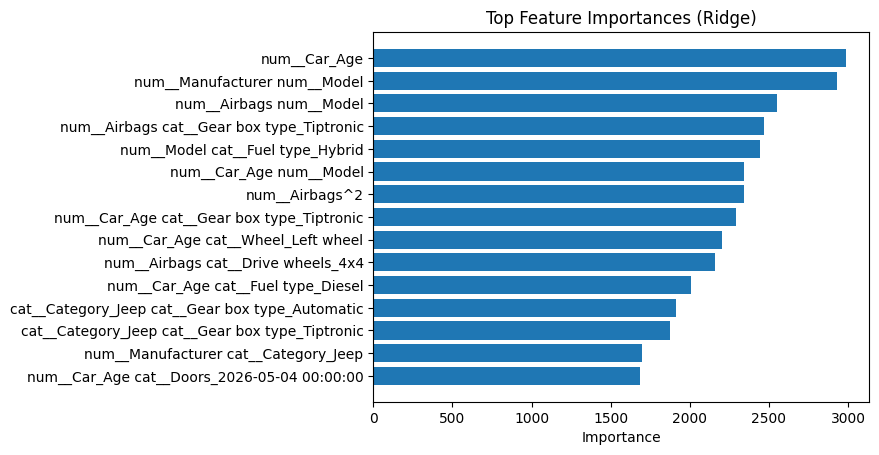

In [480]:
#Visual representation of the coefficents above
import matplotlib.pyplot as plt

top_n = 15
top_features = feat_importance.head(top_n)

plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (Ridge)")
plt.xlabel("Importance")
plt.show()

# Error Analysis by Segment
Measure Error for Manufacturer, Fuel, Car Age 

In [481]:
df_results = X_test.copy()

df_results['Actual'] = y_test.values
df_results['Predicted'] = y_pred
df_results['Error'] = abs(df_results['Actual'] - df_results['Predicted'])

# By Manufacturer
error_by_manufacturer = df_results.groupby('Manufacturer')['Error'].mean().sort_values(ascending=False)
print(error_by_manufacturer.head(10))

# By Fuel Type
error_by_fuel = df_results.groupby('Fuel type')['Error'].mean().sort_values(ascending=False)
print(error_by_fuel)

# By Car Age
error_by_age = df_results.groupby('Car_Age')['Error'].mean()
print(error_by_age.head(10))

Manufacturer
34276.929825    15550.330661
20533.606965    10579.011714
16650.398649     6988.838065
16736.760355     6940.122461
11954.834711     6463.393534
16681.528302     6292.032474
14831.781937     6170.383569
13266.929878     5500.007455
33164.593496     5184.272411
23889.009752     5168.441265
Name: Error, dtype: float64
Fuel type
Plug-in Hybrid    18944.063009
CNG                9841.330876
Petrol             7449.311086
Hybrid             6001.481211
Diesel             5260.769969
LPG                2138.163348
Name: Error, dtype: float64
Car_Age
0    21545.962387
1    16603.805107
2    10954.523226
3     9066.111499
4     6069.527608
5     7504.353778
6     6136.293129
7     5707.712146
8     5667.776972
9     4327.661933
Name: Error, dtype: float64


# Visualizations
For error indicated above in respect to MAE

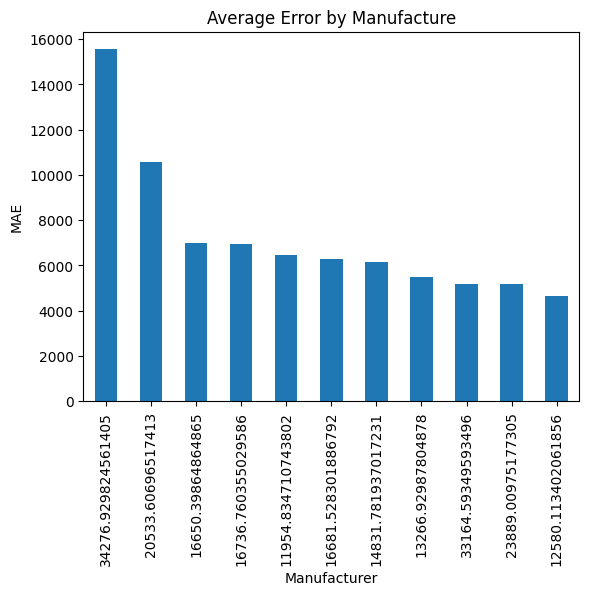

In [495]:
error_by_manufacturer.plot(kind='bar', title='Average Error by Manufacture')

plt.ylabel('MAE')
plt.show()

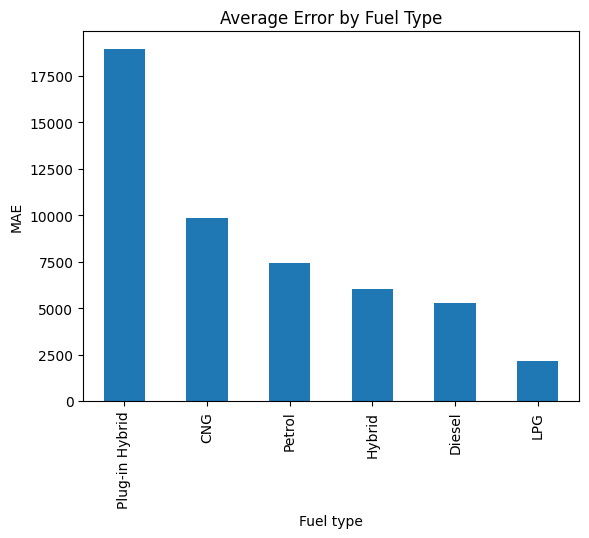

In [496]:
error_by_fuel.plot(kind='bar', title='Average Error by Fuel Type')
plt.ylabel('MAE')
plt.show()

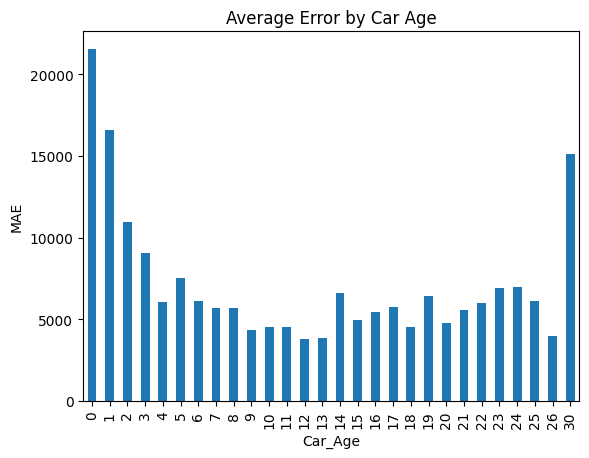

In [497]:
error_by_age.plot(kind='bar', title='Average Error by Car Age')

plt.ylabel('MAE')
plt.show()

# Thank You 😊